# Entrenamiento local — HGNN + GDELT + SP500

Notebook para ejecutar el pipeline localmente sin Colab. Config actual: **terciles + bug fixes + corte horario aplicado**.

**Requisitos**:
- Kernel: `.venv` del repo (VSCode: seleccionar en esquina superior derecha).
- Conexión internet para primera ejecución (descarga GDELT + finanzas).

**Duración estimada** (primera ejecución completa, todo desde cero):
- **Descarga GDELT raw**: 3998 CSVs → **2-3 h** (red-dependiente)
- Descarga SP500 + VIX + macro: ~30s
- Preproceso GDELT: ~35 min
- Precomputo grafos: ~3 min
- Entrenamiento walk-forward: ~5-8 min
- **Total primera vez: 3-4 h**

**Reejecuciones** (cache raw + preproc reutilizado): ~10 min total.

**Cache**:
- `data/raw/*.export.CSV` — CSVs GDELT descomprimidos
- `data/processed/` — precios SP500/VIX/macro cacheados
- `data/agregados/{aristas,participacion}/tramo_*.parquet` — agregados por tramo

## 1. Setup

In [1]:
import sys
from pathlib import Path

# Asegurar que raíz del repo está en sys.path (imports src.*)
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('ROOT:', ROOT)

import torch
print('CUDA disponible:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

ROOT: c:\Users\Ricard.Martin\Desktop\Repositorios_Kai\ai-gnn-gdelt-sp500
CUDA disponible: True
GPU: NVIDIA GeForce RTX 5070 Ti


In [2]:
from datetime import date, datetime
import numpy as np
import pandas as pd

import config

print('=== Config activa ===')
print(f'FECHA_INICIO: {config.FECHA_INICIO}')
print(f'FECHA_FIN:    {config.FECHA_FIN}')
print(f'MODO_ETIQUETA: {config.MODO_ETIQUETA}')
print(f'num_folds:    {config.WALK_FORWARD.num_folds}')
print(f'semillas:     {config.ENTRENAMIENTO.semillas}')
print(f'usar_pesos_clase: {config.ENTRENAMIENTO.usar_pesos_clase}')
print(f'LAMBDA_DECAY: {config.LAMBDA_DECAY} (vida media {np.log(2)/config.LAMBDA_DECAY:.1f}d)')
print(f'HORA_CIERRE_NY_UTC: {config.HORA_CIERRE_NY_UTC}')
print(f'dim_oculta/capas/dropout: {config.MODELO.dim_oculta}/{config.MODELO.num_capas}/{config.MODELO.dropout}')

=== Config activa ===
FECHA_INICIO: 2015-01-01
FECHA_FIN:    2025-12-31
MODO_ETIQUETA: terciles
num_folds:    10
semillas:     (0, 1, 2)
usar_pesos_clase: False
LAMBDA_DECAY: 0.0693 (vida media 10.0d)
HORA_CIERRE_NY_UTC: 21
dim_oculta/capas/dropout: 64/2/0.3


## 2. Resolver rutas raw + datos financieros

In [3]:
from src.datos.descarga_financiero import descargar_sp500, descargar_vix, descargar_macro_fred
from src.datos.descarga_gdelt import descargar_rango

FECHA_INI = date.fromisoformat(config.FECHA_INICIO)
FECHA_FIN = date.fromisoformat(config.FECHA_FIN)

# ---- GDELT raw: descarga los que falten (resumible) ----
# Si data/raw ya tiene los 3998 CSVs, esto termina rápido (solo comprueba).
# Si está vacío, descarga todo: ~2-3 h dependiendo de red.
raw = ROOT / 'data' / 'raw'
existentes = list(raw.glob('*.export.CSV'))
print(f'CSVs GDELT ya presentes: {len(existentes)}')

if len(existentes) < 3900:  # tolerancia por si faltan algunos días históricos
    print(f'Descargando GDELT desde {FECHA_INI} hasta {FECHA_FIN}...')
    print('  Esto puede tardar 2-3 horas la primera vez.')
    rutas_gdelt = descargar_rango(FECHA_INI, FECHA_FIN)
else:
    rutas_gdelt = []
    for p in sorted(existentes):
        try:
            f = datetime.strptime(p.stem.split('.')[0], '%Y%m%d').date()
            if FECHA_INI <= f <= FECHA_FIN:
                rutas_gdelt.append(p)
        except ValueError:
            continue

print(f'GDELT raw en rango: {len(rutas_gdelt)} días')

CSVs GDELT ya presentes: 3998
GDELT raw en rango: 3998 días


In [4]:
# Datos financieros: SP500 + VIX. Macro FRED opcional.
precios = descargar_sp500(FECHA_INI, FECHA_FIN)
vix = descargar_vix(FECHA_INI, FECHA_FIN)

USAR_MACRO = False   # Cambiar a True si quieres fed_funds/treasury_10y (empeoró en Exp 2)
if USAR_MACRO:
    try:
        macro = descargar_macro_fred(FECHA_INI, FECHA_FIN)
        print(f'Macro FRED: {len(macro)} filas, cols={list(macro.columns)}')
    except Exception as e:
        print(f'Macro FRED no disponible: {e}')
        macro = None
else:
    macro = None
    print('Macro FRED desactivado (USAR_MACRO=False)')

print(f'SP500: {len(precios)} sesiones | VIX: {len(vix)} puntos')

Macro FRED desactivado (USAR_MACRO=False)
SP500: 2765 sesiones | VIX: 2765 puntos


## 3. Preproceso GDELT por tramos

Genera cache en `data/agregados/`. **Resumible**: si ya hay tramos guardados, los salta. Si borraste cache, esto tardará ~35 min (23 tramos × ~1.5 min).

In [5]:
from src.datos.preprocesar import preprocesar_y_agregar_por_tramos, cargar_agregados_de_disco

DIR_AGREGADOS = ROOT / 'data' / 'agregados'
preprocesar_y_agregar_por_tramos(rutas_gdelt, DIR_AGREGADOS, dias_por_tramo=180)

17:37:17 [INFO] src.datos.preprocesar: Procesando 3998 ficheros en 23 tramos de 180 días
17:37:17 [INFO] src.datos.preprocesar: Tramo 1/23 ya en disco, se salta
17:37:17 [INFO] src.datos.preprocesar: Tramo 2/23 ya en disco, se salta
17:37:17 [INFO] src.datos.preprocesar: Tramo 3/23 ya en disco, se salta
17:37:17 [INFO] src.datos.preprocesar: Tramo 4/23 ya en disco, se salta
17:37:17 [INFO] src.datos.preprocesar: Tramo 5/23 ya en disco, se salta
17:37:17 [INFO] src.datos.preprocesar: Tramo 6/23 ya en disco, se salta
17:37:17 [INFO] src.datos.preprocesar: Tramo 7/23 ya en disco, se salta
17:37:17 [INFO] src.datos.preprocesar: Tramo 8/23 ya en disco, se salta
17:37:17 [INFO] src.datos.preprocesar: Tramo 9/23 ya en disco, se salta
17:37:17 [INFO] src.datos.preprocesar: Tramo 10/23 ya en disco, se salta
17:37:17 [INFO] src.datos.preprocesar: Tramo 11/23 ya en disco, se salta
17:37:17 [INFO] src.datos.preprocesar: Tramo 12/23 ya en disco, se salta
17:37:17 [INFO] src.datos.preprocesar: Tramo

In [6]:
df_agregado, df_participacion = cargar_agregados_de_disco(DIR_AGREGADOS)
print(f'Aristas agregadas: {len(df_agregado):,}')
print(f'Filas participación: {len(df_participacion):,}')
df_agregado.head(3)

17:37:17 [INFO] src.datos.preprocesar: Agregados cargados de disco: 2198657 aristas, 638508 participaciones
Aristas agregadas: 2,198,657
Filas participación: 638,508


,fecha,pais_origen,pais_destino,quadclass,n_eventos,goldstein_medio,tono_medio,num_mentions_total
0,2015-01-01,AUS,AUS,1,26,1.803846,2.240337,384
1,2015-01-01,AUS,AUS,2,12,5.583333,2.125634,136
2,2015-01-01,AUS,AUS,3,4,-2.500000,2.384794,44


## 4. Etiquetas + alineación temporal

In [7]:
from src.datos.etiquetas import construir_etiquetas_diarias

etiquetas = construir_etiquetas_diarias(precios)

# Alinear con fechas GDELT
fechas_gdelt = set(pd.to_datetime(df_agregado['fecha']).dt.normalize().unique())
etiquetas_validas = etiquetas[
    pd.to_datetime(etiquetas['fecha_grafo']).dt.normalize().isin(fechas_gdelt)
].reset_index(drop=True)

print(f'Etiquetas alineadas: {len(etiquetas_validas)}/{len(etiquetas)}')
print()
print('Distribución de clases (PROVISIONAL — se recalcula por fold):')
print(etiquetas_validas['clase'].value_counts().sort_index())
print()
print('Retornos target — describe:')
print(etiquetas_validas['retorno'].describe())

17:37:17 [INFO] src.datos.etiquetas: Discretización PROVISIONAL (serie completa): modo=terciles | q_inf=-0.00196 | q_sup=+0.00370
17:37:17 [INFO] src.datos.etiquetas: Etiquetas construidas: 2764 sesiones
17:37:17 [INFO] src.datos.etiquetas: Distribución de clases (PROVISIONAL, se recalcula por fold):
clase
0    921
1    922
2    921
Name: count, dtype: int64
Etiquetas alineadas: 2751/2764

Distribución de clases (PROVISIONAL — se recalcula por fold):
clase
0    919
1    919
2    913
Name: count, dtype: int64

Retornos target — describe:
count    2751.000000
mean        0.000487
std         0.011302
min        -0.119841
25%        -0.003783
50%         0.000693
75%         0.005755
max         0.095154
Name: retorno, dtype: float64


## 5. Construir dataset (precomputar grafos)

In [8]:
from src.datos.dataset import DatasetGrafoDiario
import time

t0 = time.time()
dataset = DatasetGrafoDiario(
    eventos_agregados=df_agregado,
    etiquetas=etiquetas_validas,
    precios_sp500=precios,
    macro=macro,
    vix=vix,
    participacion=df_participacion,
    precomputar=True,  # bug 3 fix: sin esto reconstruye grafos ~30 veces
)
print(f'Dataset: {len(dataset)} muestras (precomputadas en {time.time()-t0:.1f}s)')

17:37:18 [INFO] src.datos.dataset: Precomputando 2751 grafos...
17:39:59 [INFO] src.datos.dataset: Precomputación completada
Dataset: 2751 muestras (precomputadas en 161.2s)


In [9]:
# Inspección grafo día muestra
data, clase = dataset[100]
print(f'Grafo idx=100, clase real: {clase}')
print(f'Nodos country: {data["country"].x.shape}')
print(f'Nodo market:   {data["market"].x.shape}')
print(f'Aristas C-C:   {data["country","interactua","country"].edge_index.shape[1]}')
print(f'Aristas C-M:   {data["country","expone","market"].edge_index.shape[1]}')
print(f'Aristas M-C:   {data["market","influye","country"].edge_index.shape[1]}')

Grafo idx=100, clase real: 0
Nodos country: torch.Size([20, 11])
Nodo market:   torch.Size([1, 9])
Aristas C-C:   1428
Aristas C-M:   20
Aristas M-C:   20


## 6. Walk-forward + entrenamiento

In [10]:
from src.entrenamiento.walkforward import construir_folds

dispositivo = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Dispositivo:', dispositivo)

folds = construir_folds(fechas=etiquetas_validas['fecha_grafo'])
print(f'{len(folds)} folds construidos:')
for f in folds:
    print(f'  Fold {f.fold_id}: train [{f.fecha_train_inicio.date()}, {f.fecha_train_fin.date()}] n={len(f.idx_train)} | val [{f.fecha_val_inicio.date()}, {f.fecha_val_fin.date()}] n={len(f.idx_val)}')

Dispositivo: cuda
17:39:59 [INFO] src.entrenamiento.walkforward: Walk-forward: 10 folds, modo=expansiva, train inicial=250 muestras, val=250 muestras, embargo=0, N=2751, rango=2015-01-02 a 2025-12-29
17:39:59 [INFO] src.entrenamiento.walkforward:   Fold 0: train [2015-01-02, 2015-12-29] n=250 | val [2015-12-30, 2016-12-23] n=250
17:39:59 [INFO] src.entrenamiento.walkforward:   Fold 1: train [2015-01-02, 2016-12-23] n=500 | val [2016-12-27, 2017-12-21] n=250
17:39:59 [INFO] src.entrenamiento.walkforward:   Fold 2: train [2015-01-02, 2017-12-21] n=750 | val [2017-12-22, 2018-12-20] n=250
17:39:59 [INFO] src.entrenamiento.walkforward:   Fold 3: train [2015-01-02, 2018-12-20] n=1000 | val [2018-12-21, 2019-12-18] n=250
17:39:59 [INFO] src.entrenamiento.walkforward:   Fold 4: train [2015-01-02, 2019-12-18] n=1250 | val [2019-12-19, 2020-12-15] n=250
17:39:59 [INFO] src.entrenamiento.walkforward:   Fold 5: train [2015-01-02, 2020-12-15] n=1500 | val [2020-12-16, 2021-12-13] n=250
17:39:59 [I

In [11]:
from src.entrenamiento.loop import entrenar_walkforward

retornos_por_indice = etiquetas_validas['retorno'].values

resultado = entrenar_walkforward(
    dataset=dataset,
    folds=folds,
    semillas=config.ENTRENAMIENTO.semillas,
    dispositivo=dispositivo,
    retornos_por_indice=retornos_por_indice,
)
print()
print(resultado.resumen_final())

17:39:59 [INFO] src.entrenamiento.loop: ======================================================================
17:39:59 [INFO] src.entrenamiento.loop: FOLD 0  (train n=250, test n=250)
17:39:59 [INFO] src.entrenamiento.loop: ======================================================================
17:39:59 [INFO] src.entrenamiento.loop: --- Semilla 0 ---
17:39:59 [INFO] src.datos.etiquetas: Etiquetas por fold: modo=terciles | q_inf=-0.00297 | q_sup=+0.00276
17:39:59 [INFO] src.datos.etiquetas: Distribución en train del fold (baja/neutro/sube): [83, 84, 83]
17:39:59 [INFO] src.datos.normalizacion: Normalizador ajustado sobre 212 grafos de train (country 11 cols, market 9 cols, edge_cc 3 cols continuas)
17:40:04 [INFO] src.entrenamiento.loop:   Clasificación: acc=0.4040 | F1_macro=0.3563 | F1_clases=[0.175, 0.536, 0.358] | n=250
17:40:04 [INFO] src.entrenamiento.loop:   Financiero:    rent_estr=+8.90% | rent_BH=+9.96% | vs_BH=-1.06pp | sharpe=0.80 | maxDD=-10.47% | long/short/cash=136/0/114

## 7. Análisis resultados

In [12]:
from IPython.display import HTML, display
from sklearn.metrics import confusion_matrix

def mostrar_resultados(resultado):
    ms = resultado.media_y_std()

    def mstd(k, pct=False, pp=False, signo=False):
        if k not in ms: return '—'
        m, s = ms[k]
        if pct: return (f'{100*m:+.2f}% ± {100*s:.2f}%') if signo else (f'{100*m:.2f}% ± {100*s:.2f}%')
        if pp:  return f'{100*m:+.2f} pp ± {100*s:.2f} pp'
        return f'{m:.4f} ± {s:.4f}'

    f1c = np.mean([m.f1_por_clase for m in resultado.metricas_por_fold], axis=0)
    f1c_txt = ' — '.join(f'{n}: {v:.3f}' for n, v in zip(['Baja','Neutro','Sube'], f1c))

    filas = [
        ('Accuracy', mstd('accuracy'), 'Aciertos totales. Con clases balanceadas por terciles, ≥0.33 = mejor que azar.'),
        ('F1-macro', mstd('f1_macro'), 'Media F1 de 3 clases. Métrica principal en clasificación multiclase balanceada.'),
        ('F1 por clase', f1c_txt, 'F1 de cada clase por separado.'),
        ('Rent. estrategia', mstd('rent_estrategia', pct=True, signo=True), 'Retorno estrategia HGNN.'),
        ('Rent. buy & hold', mstd('rent_buy_hold', pct=True, signo=True), 'Retorno buy & hold. Referencia.'),
        ('vs Buy & Hold', mstd('rent_vs_bh', pp=True), 'Diferencia estrategia vs BH.'),
        ('Sharpe', mstd('sharpe'), 'Retorno ajustado por riesgo.'),
        ('Max drawdown', mstd('max_drawdown', pct=True), 'Peor caída pico-valle.'),
    ]
    html = '<table style="border-collapse:collapse"><tr><th style="text-align:left">Métrica</th><th>Valor</th><th style="text-align:left">Descripción</th></tr>'
    for n, v, d in filas:
        html += f'<tr><td style="padding:4px 12px;font-weight:600">{n}</td><td style="padding:4px 12px;font-family:monospace">{v}</td><td style="padding:4px 12px;color:#555">{d}</td></tr>'
    html += '</table>'

    # Matriz confusión out-of-sample (todos folds × semillas)
    y_true = np.concatenate(resultado.reales_crudas, axis=0).astype(int)
    y_pred = np.concatenate(resultado.probas_crudas, axis=0).argmax(axis=1)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    etiquetas = ['Baja', 'Neutro', 'Sube']

    html += '<h4 style="margin-top:16px;margin-bottom:8px">Matriz de confusión (filas = realidad, columnas = predicho)</h4>'
    html += '<table style="border-collapse:collapse;font-family:monospace">'
    html += '<tr><th></th>' + ''.join(f'<th style="padding:6px 14px;color:#333">{e}</th>' for e in etiquetas) + '</tr>'
    for i, fila in enumerate(cm):
        html += f'<tr><th style="padding:6px 14px;text-align:right;color:#333">{etiquetas[i]}</th>'
        for j, val in enumerate(fila):
            bg = '#c3fae8' if i == j else '#ffffff'
            html += f'<td style="padding:6px 14px;text-align:center;background:{bg};border:1px solid #e9ecef">{int(val)}</td>'
        html += '</tr>'
    html += '</table>'
    html += '<div style="color:#666;font-size:0.9em;margin-top:6px">La diagonal (en verde) son los aciertos. Fuera de la diagonal, los errores.</div>'

    display(HTML(html))

mostrar_resultados(resultado)

In [13]:
# Análisis out-of-sample crudo (todas las semillas × folds)
from sklearn.metrics import precision_recall_fscore_support

probas = np.concatenate(resultado.probas_crudas, axis=0)
y_true = np.concatenate(resultado.reales_crudas, axis=0).astype(int)
y_pred = probas.argmax(axis=1)
N = {0: 'baja', 1: 'neutro', 2: 'sube'}
n = len(y_true)

print(f'n out-of-sample = {n}\n')
print('[1] Distribución real vs predicha')
for c in [0, 1, 2]:
    print(f'  {N[c]:6s}  real {(y_true==c).sum():5d} ({100*(y_true==c).mean():4.1f}%) | pred {(y_pred==c).sum():5d} ({100*(y_pred==c).mean():4.1f}%)')

may = int(pd.Series(y_true).value_counts().idxmax())
acc_base = (y_true == may).mean()
acc_mod = (y_pred == y_true).mean()
print(f"\n  Baseline trivial 'siempre {N[may]}': acc={acc_base:.4f}")
print(f'  HGNN:                          acc={acc_mod:.4f}  -> {"SUPERA" if acc_mod>acc_base else "NO supera"} ({acc_mod-acc_base:+.4f})')

conf = probas.max(axis=1)
print(f'\n[2] Confianza media={conf.mean():.3f} | plana(<0.40)={100*(conf<0.40).mean():.0f}% | confiada(>0.70)={100*(conf>0.70).mean():.0f}%')
print('   Calibración (¿si dice conf X, acierta X?):')
for lo, hi in [(0.33,0.40),(0.40,0.50),(0.50,0.60),(0.60,0.70),(0.70,1.01)]:
    m = (conf >= lo) & (conf < hi)
    if m.sum():
        print(f'      [{lo:.2f}, {hi:.2f})  n={m.sum():5d}  acc_real={(y_pred[m]==y_true[m]).mean():.3f}')

prec, rec, f1c, sup = precision_recall_fscore_support(y_true, y_pred, labels=[0,1,2], zero_division=0)
print('\n[3] Precision / Recall por clase')
for i, c in enumerate([0,1,2]):
    print(f'   {N[c]:6s} prec={prec[i]:.3f} recall={rec[i]:.3f} f1={f1c[i]:.3f} n={int(sup[i])}')

n out-of-sample = 7500

[1] Distribución real vs predicha
  baja    real  2445 (32.6%) | pred  1832 (24.4%)
  neutro  real  2274 (30.3%) | pred  3183 (42.4%)
  sube    real  2781 (37.1%) | pred  2485 (33.1%)

  Baseline trivial 'siempre sube': acc=0.3708
  HGNN:                          acc=0.4084  -> SUPERA (+0.0376)

[2] Confianza media=0.439 | plana(<0.40)=36% | confiada(>0.70)=1%
   Calibración (¿si dice conf X, acierta X?):
      [0.33, 0.40)  n= 2665  acc_real=0.356
      [0.40, 0.50)  n= 3516  acc_real=0.436
      [0.50, 0.60)  n= 1063  acc_real=0.443
      [0.60, 0.70)  n=  186  acc_real=0.441
      [0.70, 1.01)  n=   70  acc_real=0.414

[3] Precision / Recall por clase
   baja   prec=0.334 recall=0.250 f1=0.286 n=2445
   neutro prec=0.426 recall=0.596 f1=0.497 n=2274
   sube   prec=0.441 recall=0.394 f1=0.416 n=2781


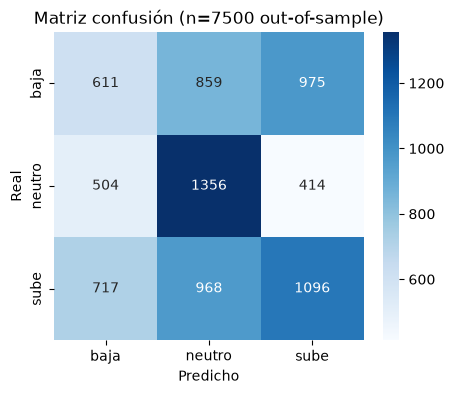

In [14]:
# Matriz confusión
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['baja','neutro','sube'],
            yticklabels=['baja','neutro','sube'])
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.title(f'Matriz confusión (n={n} out-of-sample)')
plt.show()

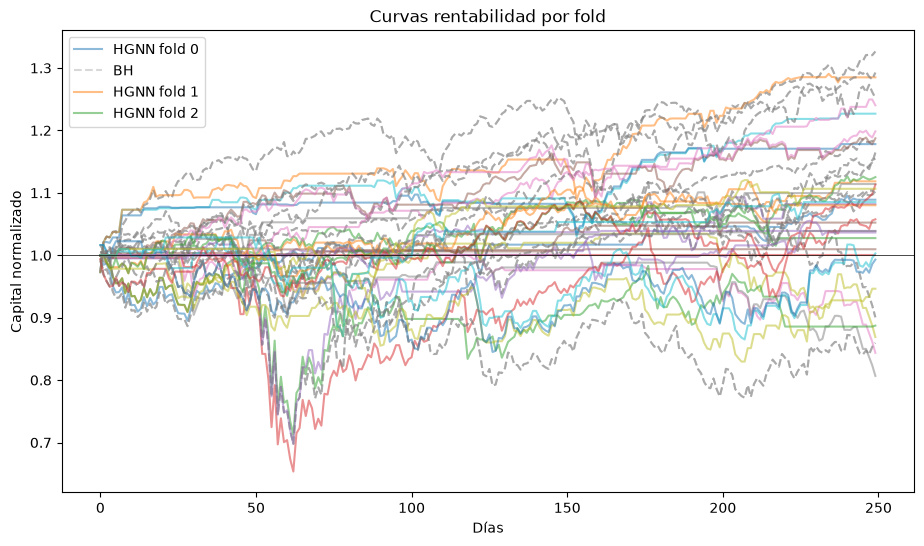

In [15]:
# Curvas rentabilidad por fold
plt.figure(figsize=(11, 6))
for i, mf in enumerate(resultado.metricas_financieras_por_fold):
    plt.plot(mf.curva_estrategia, alpha=0.5, label=f'HGNN fold {i}' if i<3 else None)
    plt.plot(mf.curva_buy_hold, alpha=0.3, color='gray', linestyle='--', label='BH' if i==0 else None)
plt.axhline(1.0, color='black', linewidth=0.5)
plt.ylabel('Capital normalizado')
plt.xlabel('Días')
plt.title('Curvas rentabilidad por fold')
plt.legend()
plt.show()

## 8. Análisis extendido (baselines, calibración, magnitud aciertos)

### 8.1 Distribución clases y retornos

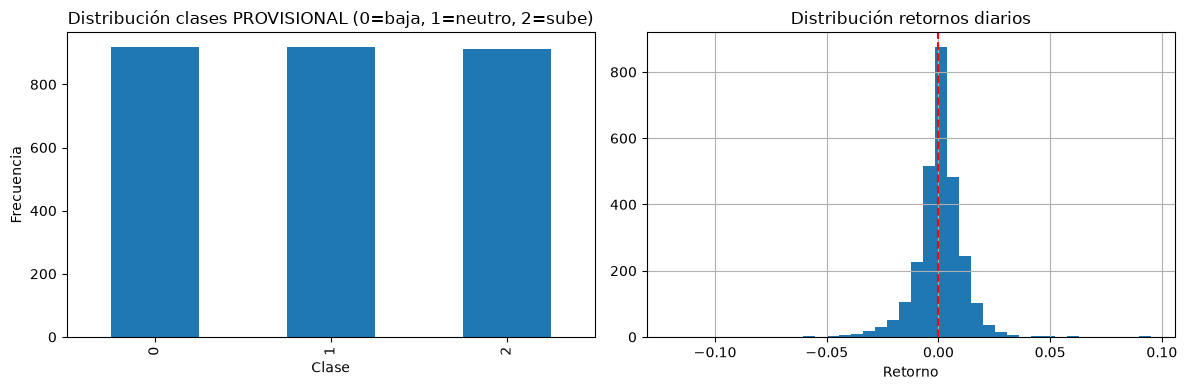

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
etiquetas_validas['clase'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0],
    title='Distribución clases PROVISIONAL (0=baja, 1=neutro, 2=sube)')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Frecuencia')

etiquetas_validas['retorno'].hist(bins=40, ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Distribución retornos diarios')
axes[1].set_xlabel('Retorno')
plt.tight_layout()
plt.show()

### 8.2 Día con más actividad geopolítica

In [17]:
fecha_max = df_agregado.groupby('fecha')['n_eventos'].sum().idxmax()
n_max = df_agregado.groupby('fecha')['n_eventos'].sum().max()
print(f'Día más activo: {fecha_max.date()} con {n_max} eventos agregados')
print()
print('Top 15 aristas ese día:')
df_agregado[df_agregado['fecha'] == fecha_max].sort_values('n_eventos', ascending=False).head(15)

Día más activo: 2018-05-09 con 17361 eventos agregados

Top 15 aristas ese día:


,fecha,pais_origen,pais_destino,quadclass,n_eventos,goldstein_medio,tono_medio,num_mentions_total
762882,2018-05-09,USA,USA,1,1243,2.280772,-1.212737,39819
762885,2018-05-09,USA,USA,4,360,-7.559722,-5.076091,10843
762710,2018-05-09,PRK,USA,1,359,2.598050,-1.052368,45823
762883,2018-05-09,USA,USA,2,358,5.645810,-1.790943,16989
762863,2018-05-09,USA,PRK,1,347,2.731412,-0.648440,42173
762884,2018-05-09,USA,USA,3,293,-3.143686,-3.933373,8852
762843,2018-05-09,USA,IRN,1,286,3.120280,-2.163516,7914
762844,2018-05-09,USA,IRN,2,238,8.788235,-2.460088,12167
762605,2018-05-09,JPN,CHN,1,225,3.303111,0.562461,13213
762561,2018-05-09,IRN,USA,1,204,3.092647,-2.305391,7940


### 8.3 Historial entrenamiento fold 0 (train loss + val interna)

17:44:46 [INFO] src.datos.etiquetas: Etiquetas por fold: modo=terciles | q_inf=-0.00297 | q_sup=+0.00276
17:44:46 [INFO] src.datos.etiquetas: Distribución en train del fold (baja/neutro/sube): [83, 84, 83]
17:44:46 [INFO] src.datos.normalizacion: Normalizador ajustado sobre 212 grafos de train (country 11 cols, market 9 cols, edge_cc 3 cols continuas)


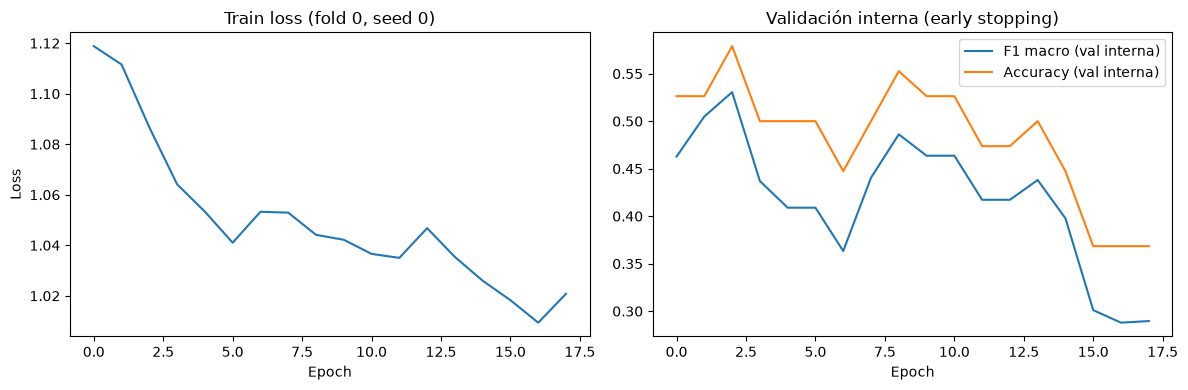

Fold 0 test: acc=0.4040 | F1_macro=0.3563 | F1_clases=[0.175, 0.536, 0.358] | n=250


In [18]:
from src.entrenamiento.loop import entrenar_un_fold
import matplotlib.pyplot as plt

f0 = folds[0]
m0, hist, *_ = entrenar_un_fold(
    dataset, f0.idx_train, f0.idx_val,
    seed=0, dispositivo=dispositivo, verbose=False,
    retornos_por_indice=retornos_por_indice,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist['train_loss'])
axes[0].set_title('Train loss (fold 0, seed 0)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(hist['val_f1'], label='F1 macro (val interna)')
axes[1].plot(hist['val_acc'], label='Accuracy (val interna)')
axes[1].set_title('Validación interna (early stopping)')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'Fold 0 test: {m0.resumen()}')

### 8.4 Baselines clásicos (naive, logística, XGBoost)

In [19]:
from src.modelo.baselines import (
    BaselineNaive, construir_matriz_features,
    entrenar_logistica, entrenar_xgboost,
)
from src.datos.etiquetas import clases_para_fold
from src.entrenamiento.evaluacion import calcular_metricas

X, _ = construir_matriz_features(dataset)
print('X shape:', X.shape)

f0 = folds[0]
y_fold, umbrales_f0 = clases_para_fold(retornos_por_indice, f0.idx_train)
print('Umbrales fold 0:', umbrales_f0.resumen())

X_tr, y_tr = X[f0.idx_train], y_fold[f0.idx_train]
X_va, y_va = X[f0.idx_val], y_fold[f0.idx_val]

naive = BaselineNaive().fit(X_tr, y_tr)
logr = entrenar_logistica(X_tr, y_tr)
xgb = entrenar_xgboost(X_tr, y_tr)

print()
print(f'{"Modelo":>12s}  Acc     F1_macro  F1_baja  F1_neu  F1_sube')
for nombre, modelo in [('naive', naive), ('logística', logr), ('xgboost', xgb)]:
    m = calcular_metricas(y_va, modelo.predict(X_va))
    f1c = m.f1_por_clase
    print(f'{nombre:>12s}  {m.accuracy:.4f}  {m.f1_macro:.4f}    '
          f'{f1c[0]:.3f}    {f1c[1]:.3f}   {f1c[2]:.3f}')

X shape: (2751, 45)
17:44:48 [INFO] src.datos.etiquetas: Etiquetas por fold: modo=terciles | q_inf=-0.00297 | q_sup=+0.00276
17:44:48 [INFO] src.datos.etiquetas: Distribución en train del fold (baja/neutro/sube): [83, 84, 83]
Umbrales fold 0: modo=terciles | q_inf=-0.00297 | q_sup=+0.00276
17:44:48 [INFO] src.modelo.baselines: Naive: clase mayoritaria = 1 (33.6%)

      Modelo  Acc     F1_macro  F1_baja  F1_neu  F1_sube
       naive  0.3960  0.1891    0.000    0.567   0.000
   logística  0.3400  0.3013    0.385    0.443   0.075
     xgboost  0.3520  0.3250    0.310    0.190   0.475


### 8.5 Matrices confusión baselines

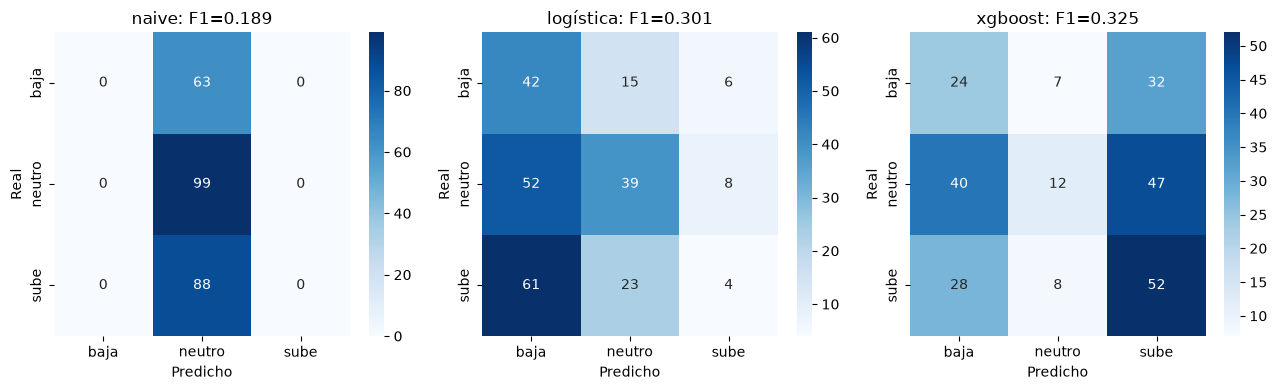

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (nombre, modelo) in zip(axes, [('naive', naive), ('logística', logr), ('xgboost', xgb)]):
    m = calcular_metricas(y_va, modelo.predict(X_va))
    sns.heatmap(m.matriz_confusion, annot=True, fmt='d', cmap='Blues',
                xticklabels=['baja', 'neutro', 'sube'],
                yticklabels=['baja', 'neutro', 'sube'], ax=ax)
    ax.set_title(f'{nombre}: F1={m.f1_macro:.3f}')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicho')
plt.tight_layout()
plt.show()

### 8.6 Barrido umbral short + magnitud aciertos

In [21]:
# ============================================================
# RESUMEN OUT-OF-SAMPLE COMPLETO
# Concatena predicciones de TODOS los (fold × semilla). Todo es validación.
# Replica el análisis de la celda 33 del notebook Colab original.
# ============================================================
import numpy as np, pandas as pd
from sklearn.metrics import precision_recall_fscore_support

probas_all = np.concatenate(resultado.probas_crudas, axis=0)
y_true = np.concatenate(resultado.reales_crudas, axis=0).astype(int)
retornos_test = np.concatenate(
    [r for r in resultado.retornos_crudos if r is not None], axis=0
).astype(float)
y_pred = probas_all.argmax(axis=1)
N = {0: "baja", 1: "neutro", 2: "sube"}
n = len(y_true)
print(f"n out-of-sample (folds × semillas) = {n}\n")

# [1] DISTRIBUCIÓN real vs predicha + baseline mayoritario
print("[1] DISTRIBUCIÓN real vs predicha")
for c in [0, 1, 2]:
    print(f"  {N[c]:6} real {(y_true==c).sum():5d} ({100*(y_true==c).mean():4.1f}%) | "
          f"pred {(y_pred==c).sum():5d} ({100*(y_pred==c).mean():4.1f}%)")
may = int(pd.Series(y_true).value_counts().idxmax())
acc_base = (y_true == may).mean()
acc_mod = (y_pred == y_true).mean()
print(f"  baseline 'siempre {N[may]}': acc={acc_base:.4f}")
print(f"  modelo:                 acc={acc_mod:.4f}  -> "
      f"{'SUPERA' if acc_mod>acc_base else 'NO supera'} ({acc_mod-acc_base:+.4f})")

# [2] CONFIANZA + CALIBRACIÓN
conf = probas_all.max(axis=1)
print(f"\n[2] CONFIANZA  media={conf.mean():.3f}  "
      f"plana(<0.40)={100*(conf<0.40).mean():.0f}%  confiada(>0.70)={100*(conf>0.70).mean():.0f}%")
print("    calibración (si dice conf X, ¿acierta X?):")
for lo, hi in [(0.33,0.40),(0.40,0.50),(0.50,0.60),(0.60,0.70),(0.70,1.01)]:
    m = (conf >= lo) & (conf < hi)
    if m.sum():
        print(f"      [{lo:.2f},{hi:.2f}) n={m.sum():5d} acc_real={(y_pred[m]==y_true[m]).mean():.3f}")

# [4] PRECISION/RECALL POR CLASE (foco en 'baja')
prec, rec, f1c, sup = precision_recall_fscore_support(
    y_true, y_pred, labels=[0,1,2], zero_division=0)
print("\n[4] por clase  (recall de 'baja' bajo -> el short no tiene base)")
for i, c in enumerate([0,1,2]):
    print(f"   {N[c]:6} prec={prec[i]:.3f} recall={rec[i]:.3f} f1={f1c[i]:.3f} n={int(sup[i])}")

# [3] BARRIDO UMBRAL_SHORT
print("\n[3] BARRIDO UMBRAL_SHORT (rent/sharpe/maxDD/#short)")
for u in [0.40,0.50,0.60,0.70,0.80,0.90]:
    pos = np.zeros(n); cur = 0
    for i in range(n):
        c = y_pred[i]
        if c == 2: cur = 1
        elif c == 0: cur = -1 if probas_all[i,0] >= u else 0
        pos[i] = cur
    re = pos * retornos_test
    curva = np.cumprod(1 + re)
    sh = np.sqrt(252)*re.mean()/re.std(ddof=1) if re.std(ddof=1) > 1e-12 else 0
    dd = ((curva - np.maximum.accumulate(curva)) / np.maximum.accumulate(curva)).min()
    print(f"   u={u:.2f} rent={100*(curva[-1]-1):+6.1f}% sharpe={sh:5.2f} "
          f"maxDD={100*dd:6.1f}% short={int((pos==-1).sum())}")
print(f"   Buy&Hold = {100*(np.cumprod(1+retornos_test)[-1]-1):+.1f}%")

# [5] MAGNITUD DE ACIERTOS Y ERRORES
print("\n[5] MAGNITUD DE ACIERTOS Y ERRORES (no todos los días pesan igual)")
signo_real = np.sign(retornos_test)
apuesta = np.where(y_pred==2, 1, np.where(y_pred==0, -1, 0))
mojado = apuesta != 0
acierto_dir = (np.sign(retornos_test[mojado]) == apuesta[mojado])
mag = np.abs(retornos_test[mojado])
print(f"  días que se moja (no neutro): {mojado.sum()} de {n}")
print(f"  |retorno| medio cuando ACIERTA dirección: {100*mag[acierto_dir].mean():.3f}%")
print(f"  |retorno| medio cuando FALLA  dirección: {100*mag[~acierto_dir].mean():.3f}%")
print("  >> si aciertas en los días GRANDES y fallas en los pequeños, es buena señal")

for c, nom in [(2,"sube"), (0,"baja")]:
    mask = y_pred==c
    if mask.sum():
        captura = retornos_test[mask] * (1 if c==2 else -1)
        print(f"  cuando predice {nom:5} (n={mask.sum():4d}): "
              f"retorno medio capturado = {100*captura.mean():+.3f}%  "
              f"(% veces positivo: {100*(captura>0).mean():.0f}%)")

captura_total = (apuesta * retornos_test)
movimiento_total = np.abs(retornos_test).sum()
print(f"\n  Acierto ponderado por magnitud:")
print(f"    retorno neto capturado (suma): {100*captura_total.sum():+.1f}%")
print(f"    de un movimiento total de:     {100*movimiento_total:.1f}%")
print(f"    ratio capturado/disponible:    {captura_total.sum()/movimiento_total:+.3f}")
print("    >> +1.0 sería capturar TODO el movimiento; 0 = no captura nada; negativo = juega en contra")

# [6] ¿El 'neutro' son días planos de verdad?
print("\n[6] ¿EL 'NEUTRO' SON DÍAS PLANOS DE VERDAD?")
mask_neutro = y_pred == 1
if mask_neutro.sum():
    r_neutro = np.abs(retornos_test[mask_neutro])
    r_resto = np.abs(retornos_test[~mask_neutro])
    print(f"  predice neutro {mask_neutro.sum()} días")
    print(f"  |retorno| medio esos días:        {100*r_neutro.mean():.3f}%")
    print(f"  |retorno| medio el resto de días: {100*r_resto.mean():.3f}%")
    print("  >> si el neutro tiene |retorno| MENOR que el resto, el modelo distingue días planos")
    print("  >> si es parecido, 'neutro' es un cajón de sastre (no aprende, solo descarta)")

n out-of-sample (folds × semillas) = 7500

[1] DISTRIBUCIÓN real vs predicha
  baja   real  2445 (32.6%) | pred  1832 (24.4%)
  neutro real  2274 (30.3%) | pred  3183 (42.4%)
  sube   real  2781 (37.1%) | pred  2485 (33.1%)
  baseline 'siempre sube': acc=0.3708
  modelo:                 acc=0.4084  -> SUPERA (+0.0376)

[2] CONFIANZA  media=0.439  plana(<0.40)=36%  confiada(>0.70)=1%
    calibración (si dice conf X, ¿acierta X?):
      [0.33,0.40) n= 2665 acc_real=0.356
      [0.40,0.50) n= 3516 acc_real=0.436
      [0.50,0.60) n= 1063 acc_real=0.443
      [0.60,0.70) n=  186 acc_real=0.441
      [0.70,1.01) n=   70 acc_real=0.414

[4] por clase  (recall de 'baja' bajo -> el short no tiene base)
   baja   prec=0.334 recall=0.250 f1=0.286 n=2445
   neutro prec=0.426 recall=0.596 f1=0.497 n=2274
   sube   prec=0.441 recall=0.394 f1=0.416 n=2781

[3] BARRIDO UMBRAL_SHORT (rent/sharpe/maxDD/#short)
   u=0.40 rent=+195.3% sharpe= 0.30 maxDD= -59.2% short=1479
   u=0.50 rent=+353.4% sharpe= 0

### 8.7 Visualización grafo interactivo (pyvis)

Requiere `pyvis`. Instalar con `.venv/Scripts/pip install pyvis` si falta.
Genera HTML interactivo abrible en navegador.

In [22]:
import numpy as np
from pyvis.network import Network
from src.utils.paises import ROSTER, INDICE_A_PAIS

def visualizar_grafo_limpio(data, fecha=None, top_aristas_cc=15, archivo='grafo.html'):
    """Genera visualización interactiva HTML del grafo heterogéneo de un día.

    - Aristas país↔país agrupadas por par (suma QuadClass), top N por peso
    - Color arista: rojo=conflicto, verde=cooperación, gris=mixto
    - Color nodo país por Goldstein medio
    - Aristas país→SP500 (dashed) con grosor según comercio
    """
    net = Network(height='800px', width='100%', directed=True,
                  notebook=False, cdn_resources='in_line', bgcolor='#ffffff')

    ei_cc = data['country', 'interactua', 'country'].edge_index.cpu().numpy()
    ea_cc = data['country', 'interactua', 'country'].edge_attr.cpu().numpy()

    agrupado = {}
    for k in range(ei_cc.shape[1]):
        o, d = int(ei_cc[0, k]), int(ei_cc[1, k])
        peso = float(ea_cc[k, 0])
        quad = int(ea_cc[k, 3:7].argmax())
        es_conflicto = quad >= 2
        key = (o, d)
        if key not in agrupado:
            agrupado[key] = {'peso': 0.0, 'coop': 0.0, 'conf': 0.0}
        agrupado[key]['peso'] += peso
        if es_conflicto:
            agrupado[key]['conf'] += peso
        else:
            agrupado[key]['coop'] += peso

    pares_ordenados = sorted(agrupado.items(), key=lambda x: x[1]['peso'], reverse=True)
    top_pares = pares_ordenados[:top_aristas_cc]

    paises_activos = set()
    for (o, d), _ in top_pares:
        paises_activos.add(o)
        paises_activos.add(d)

    ei_cm = data['country', 'expone', 'market'].edge_index.cpu().numpy()
    ea_cm = data['country', 'expone', 'market'].edge_attr.cpu().numpy()
    for j in range(ei_cm.shape[1]):
        if float(ea_cm[j, 0]) > 0.05:
            paises_activos.add(int(ei_cm[0, j]))

    for i in paises_activos:
        p = ROSTER[i]
        feats = data['country'].x[i].tolist()
        tono = float(feats[0])
        goldstein = float(feats[1])
        if goldstein < -1: color = '#ff8787'
        elif goldstein > 1: color = '#8ce99a'
        else: color = '#a5d8ff'
        titulo = f'<b>{p.nombre}</b><br>Tono: {tono:.2f}<br>Goldstein: {goldstein:.2f}'
        net.add_node(p.id, label=p.id, title=titulo,
                     color=color, size=22, font={'size': 14, 'face': 'arial'})

    sp = data['market'].x[0].tolist()
    titulo_sp = (f'<b>S&P 500</b><br>Retorno 1d: {float(sp[0]):.4f}<br>'
                 f'Volatilidad 21d: {float(sp[3]):.4f}')
    net.add_node('SP500', label='SP500', title=titulo_sp,
                 color='#ffd43b', size=38, shape='diamond',
                 font={'size': 16, 'face': 'arial'})

    pesos_top = np.array([v['peso'] for _, v in top_pares])
    peso_max = float(pesos_top.max()) if len(pesos_top) else 1.0

    for (o, d), v in top_pares:
        origen_id = INDICE_A_PAIS[o]
        destino_id = INDICE_A_PAIS[d]
        ancho = float(1.0 + 5.0 * (v['peso'] / peso_max))
        if v['conf'] > v['coop'] * 1.2: color = '#e03131'
        elif v['coop'] > v['conf'] * 1.2: color = '#2f9e44'
        else: color = '#868e96'
        titulo = (f'{origen_id} -> {destino_id}<br>'
                  f'Peso total: {float(v["peso"]):.2f}<br>'
                  f'Cooperación: {float(v["coop"]):.2f}<br>'
                  f'Conflicto: {float(v["conf"]):.2f}')
        net.add_edge(origen_id, destino_id, width=ancho, color=color, title=titulo)

    pesos_cm = ea_cm[:, 0]
    peso_cm_max = float(pesos_cm.max()) if len(pesos_cm) else 1.0
    for j in range(ei_cm.shape[1]):
        idx_pais = int(ei_cm[0, j])
        if idx_pais not in paises_activos:
            continue
        peso = float(ea_cm[j, 0])
        if peso <= 0.05:
            continue
        origen_id = INDICE_A_PAIS[idx_pais]
        ancho = float(0.5 + 3.5 * (peso / peso_cm_max))
        net.add_edge(origen_id, 'SP500', width=ancho, color='#ffa94d',
                     dashes=True, title=f'Comercio {origen_id}<->USA: {peso:.3f}')

    net.set_options('''
    {
      "physics": {
        "forceAtlas2Based": {"gravitationalConstant": -80, "centralGravity": 0.01,
          "springLength": 150, "springConstant": 0.08},
        "solver": "forceAtlas2Based",
        "stabilization": {"iterations": 200}
      },
      "edges": {"arrows": {"to": {"enabled": true, "scaleFactor": 0.5}},
                "smooth": {"type": "curvedCW", "roundness": 0.15}},
      "interaction": {"hover": true}
    }
    ''')

    html = net.generate_html(notebook=False)
    with open(archivo, 'w', encoding='utf-8') as f:
        f.write(html)
    print(f'HTML generado: {archivo}')
    print(f'Abrir en navegador o embebido a continuación.')
    return archivo


# Genera visualización del primer día del dataset
data0, clase0 = dataset[0]
fecha0 = etiquetas_validas.iloc[0]['fecha_grafo']
archivo = visualizar_grafo_limpio(data0, fecha=fecha0, top_aristas_cc=15,
                                   archivo='grafo_dia0.html')

# Embeber en el notebook
from IPython.display import IFrame
IFrame(archivo, width='100%', height=800)

HTML generado: grafo_dia0.html
Abrir en navegador o embebido a continuación.
